# KNNRouter - Training

This notebook demonstrates how to train the **KNNRouter** (K-Nearest Neighbors Router).

## Overview

KNNRouter uses a K-Nearest Neighbors classifier to route queries to the most suitable LLM based on:
- Query embeddings (using Longformer)
- Historical performance data

**Key Features**:
- Simple and interpretable
- Fast training and inference
- Works well with limited training data

## 1. Environment Setup

In [1]:
# Install required packages (for Colab)
!git clone https://github.com/ulab-uiuc/LLMRouter.git
%cd LLMRouter
!pip install -e .
!pip install scikit-learn transformers torch

Cloning into 'LLMRouter'...
remote: Enumerating objects: 5897, done.
remote: Counting objects: 100% (212/212), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 5897 (delta 102), reused 112 (delta 77), pack-reused 5685 (from 1)
Receiving objects: 100% (5897/5897), 88.90 MiB | 55.07 MiB/s, done.
Resolving deltas: 100% (2881/2881), done.
Updating files: 100% (280/280), done.
/home/zhongjie/LLMRouter
Obtaining file:///home/zhongjie/LLMRouter
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llmrouter-lib (pyproject.toml) ... done
  Created wheel for llmrouter-lib: filename=llmrouter_lib-0.1.1-0.editable-py3-none-any.whl size=14451 sha256=119e4af13ede197b2881f7a0166c72c828683560b6a0073e246276c39d125995
  Stored in directory: /tmp/pip-ephem-wheel-cache-ocl_w7jy/wheels/82/4a/fd/59c4aec93c356c

In [ ]:
import os
os.environ['OPENAI_API_KEY'] = 'your-key'
os.environ['ANTHROPIC_API_KEY'] = 'your-key'
# Or for multiple keys:
os.environ['API_KEYS'] = '["key1", "key2"]'

In [ ]:
# Import required modules
from llmrouter.models.knnrouter import KNNRouter, KNNRouterTrainer
from llmrouter.utils import setup_environment

setup_environment()
print("Environment setup complete!")

## 2. Configuration

KNNRouter uses the following configuration parameters:

| Parameter | Description | Default |
|-----------|-------------|--------|
| `n_neighbors` | Number of neighbors (K value) | 5 |
| `weights` | Weight function: "uniform" or "distance" | "uniform" |
| `algorithm` | Algorithm: "auto", "ball_tree", "kd_tree", "brute" | "auto" |
| `metric` | Distance metric | "minkowski" |
| `p` | Power for Minkowski metric (1=Manhattan, 2=Euclidean) | 2 |

In [6]:
import yaml

# Configuration file path
CONFIG_PATH = "configs/model_config_train/knnrouter.yaml"

# Load and display configuration
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

print("Current Configuration:")
print("=" * 50)
print(yaml.dump(config, default_flow_style=False))

Current Configuration:
data_path:
  llm_data: data/example_data/llm_candidates/default_llm.json
  llm_embedding_data: data/example_data/llm_candidates/default_llm_embeddings.json
  query_data_test: data/example_data/query_data/default_query_test.jsonl
  query_data_train: data/example_data/query_data/default_query_train.jsonl
  query_embedding_data: data/example_data/routing_data/query_embeddings_longformer.pt
  routing_data_test: data/example_data/routing_data/default_routing_test_data.jsonl
  routing_data_train: data/example_data/routing_data/default_routing_train_data.jsonl
hparam:
  algorithm: auto
  leaf_size: 30
  metric: minkowski
  n_jobs: -1
  n_neighbors: 5
  p: 2
  weights: uniform
metric:
  weights:
    cost: 0
    llm_judge: 0
    performance: 1
model_path:
  ini_model_path: ''
  save_model_path: saved_models/knnrouter/knnrouter.pkl



In [5]:
# Optionally modify configuration
# You can create a custom config for experimentation

CUSTOM_CONFIG = {
    'data_path': {
        'query_data_train': 'data/example_data/query_data/default_query_train.jsonl',
        'query_data_test': 'data/example_data/query_data/default_query_test.jsonl',
        'query_embedding_data': 'data/example_data/routing_data/query_embeddings_longformer.pt',
        'routing_data_train': 'data/example_data/routing_data/default_routing_train_data.jsonl',
        'routing_data_test': 'data/example_data/routing_data/default_routing_test_data.jsonl',
        'llm_data': 'data/example_data/llm_candidates/default_llm.json',
        'llm_embedding_data': 'data/example_data/llm_candidates/default_llm_embeddings.json'
    },
    'model_path': {
        'ini_model_path': '',
        'save_model_path': 'saved_models/knnrouter/knnrouter.pkl'
    },
    'metric': {
        'weights': {
            'performance': 1,
            'cost': 0,
            'llm_judge': 0
        }
    },
    'hparam': {
        'n_neighbors': 5,
        'weights': 'uniform',
        'algorithm': 'auto',
        'leaf_size': 30,
        'p': 2,
        'metric': 'minkowski',
        'n_jobs': -1
    }
}

# Save custom config (optional)
# custom_config_path = 'configs/model_config_train/knnrouter_custom.yaml'
# with open(custom_config_path, 'w') as f:
#     yaml.dump(CUSTOM_CONFIG, f)
# print(f"Custom config saved to {custom_config_path}")

## 3. Initialize Router

In [7]:
# Initialize KNNRouter with configuration
router = KNNRouter(yaml_path=CONFIG_PATH)

print("Router initialized successfully!")
print(f"Number of training samples: {len(router.routing_data_train)}")
print(f"Number of LLM candidates: {len(router.llm_data)}")
print(f"LLM candidates: {list(router.llm_data.keys())}")

✅ MetaRouter initialized successfully (YAML + data loaded).
Router initialized successfully!
Number of training samples: 50544
Number of LLM candidates: 14
LLM candidates: ['qwen2.5-7b-instruct', 'codegemma-7b', 'gemma-2-9b-it', 'llama-3.1-8b-instruct', 'llama3-chatqa-1.5-8b', 'mistral-7b-instruct-v0.3', 'llama-3.3-nemotron-super-49b-v1', 'llama-3.1-nemotron-51b-instruct', 'llama3-chatqa-1.5-70b', 'llama3-70b-instruct', 'mixtral-8x7b-instruct-v0.1', 'mixtral-8x22b-instruct-v0.1', 'palmyra-creative-122b', 'mistral-nemo-12b-instruct']


In [8]:
# Inspect the KNN model configuration
print("KNN Model Parameters:")
print(router.knn_model.get_params())

KNN Model Parameters:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


## 4. Data Exploration

In [9]:
import pandas as pd

# Explore training data
train_df = router.routing_data_train
print("Training Data Shape:", train_df.shape)
print("\nColumns:", list(train_df.columns))
print("\nSample data:")
train_df.head()

Training Data Shape: (50544, 17)

Columns: ['task_name', 'query', 'ground_truth', 'metric', 'choices', 'task_id', 'model_name', 'response', 'token_num', 'input_tokens', 'output_tokens', 'response_time', 'api_key_used', 'performance', 'embedding_id', 'user_id', 'fig_id']

Sample data:


,task_name,query,ground_truth,metric,choices,task_id,model_name,response,token_num,input_tokens,output_tokens,response_time,api_key_used,performance,embedding_id,user_id,fig_id
0,agentverse-logicgrid,"Q: There are 3 houses in a row, numbered 1 on ...",C,em_mc,"{'text': ['1', '2', '3'], 'labels': ['A', 'B',...",None,llama3-chatqa-1.5-8b,B. labels,453,449,4,1.786449,rivTkKeBPm,0.0,61,None,None
1,agentverse-logicgrid,"Q: There are 4 houses in a row, numbered 1 on ...",B,em_mc,"{'text': ['1', '2', '3', '4'], 'labels': ['A',...",None,llama3-chatqa-1.5-8b,B. labels,522,518,4,1.808008,07iTpWkg53,0.0,144,None,None
2,agentverse-logicgrid,"Q: There are 3 houses in a row, numbered 1 on ...",C,em_mc,"{'text': ['1', '2', '3'], 'labels': ['A', 'B',...",None,qwen2.5-7b-instruct,C,413,412,1,3.261811,rivTkKeBPm,0.0,61,None,None
3,agentverse-logicgrid,"Q: There are 4 houses in a row, numbered 1 on ...",B,em_mc,"{'text': ['1', '2', '3', '4'], 'labels': ['A',...",None,qwen2.5-7b-instruct,D,484,483,1,3.276698,oE9VxHtPRB,0.0,144,None,None
4,agentverse-logicgrid,"Q: There are 3 houses in a row, numbered 1 on ...",A,em_mc,"{'text': ['1', '2', '3'], 'labels': ['A', 'B',...",None,qwen2.5-7b-instruct,C,384,383,1,3.278904,hgicYjBYxR,0.0,75,None,None


In [10]:
# Analyze performance distribution
print("Performance Statistics:")
print(train_df['performance'].describe())

print("\nPerformance by Model:")
print(train_df.groupby('model_name')['performance'].mean().sort_values(ascending=False))

Performance Statistics:
count    50544.000000
mean         0.428694
std          0.489734
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: performance, dtype: float64

Performance by Model:
model_name
llama-3.1-nemotron-51b-instruct    0.621506
llama-3.3-nemotron-super-49b-v1    0.578728
llama-3.1-8b-instruct              0.560574
gemma-2-9b-it                      0.534966
qwen2.5-7b-instruct                0.519796
mistral-7b-instruct-v0.3           0.371144
codegemma-7b                       0.302852
llama3-chatqa-1.5-70b              0.193845
llama3-chatqa-1.5-8b               0.174838
Name: performance, dtype: float64


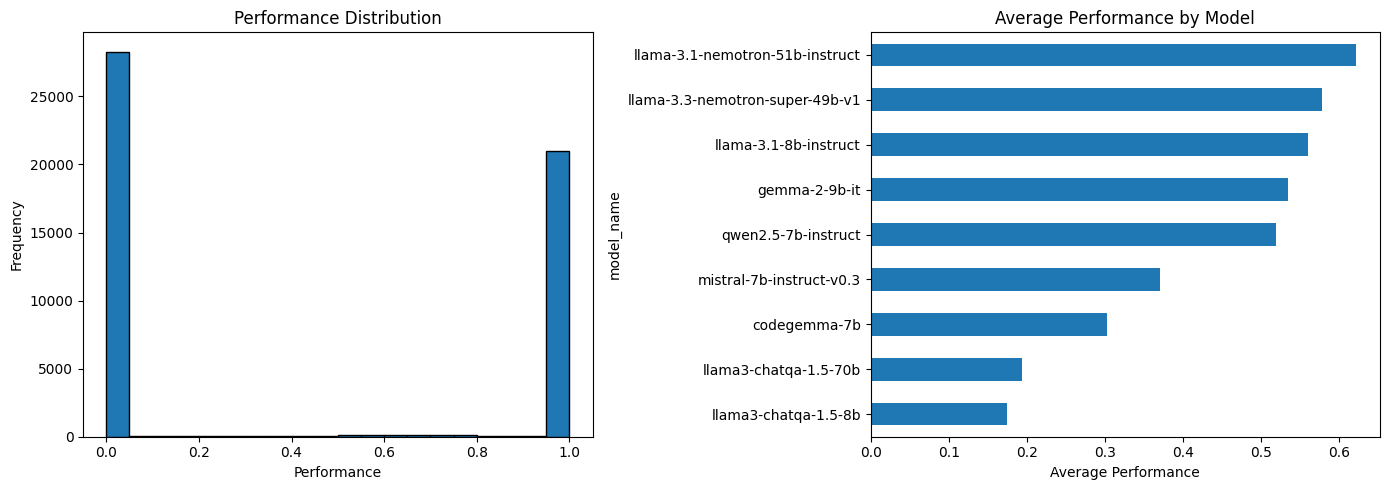

In [11]:
# Visualize performance distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Performance histogram
axes[0].hist(train_df['performance'], bins=20, edgecolor='black')
axes[0].set_xlabel('Performance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Performance Distribution')

# Performance by model
model_perf = train_df.groupby('model_name')['performance'].mean().sort_values()
model_perf.plot(kind='barh', ax=axes[1])
axes[1].set_xlabel('Average Performance')
axes[1].set_title('Average Performance by Model')

plt.tight_layout()
plt.show()

## 5. Training

In [12]:
# Initialize trainer
trainer = KNNRouterTrainer(router=router, device='cpu')

print("Trainer initialized!")
print(f"Training samples: {len(trainer.query_embedding_list)}")
print(f"Save path: {trainer.save_model_path}")

[KNNRouterTrainer] Initialized with router.
Trainer initialized!
Training samples: 5608
Save path: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl


In [13]:
# Train the model
print("Starting training...")
print("=" * 50)

trainer.train()

print("=" * 50)
print("Training completed!")

Starting training...
Created directory: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter
Successfully saved pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Training completed!


## 6. Model Verification

In [14]:
# Verify the trained model
from llmrouter.utils import load_model

# Load the saved model
saved_model = load_model(trainer.save_model_path)

print("Model loaded successfully!")
print(f"Model type: {type(saved_model).__name__}")
print(f"Number of classes: {len(saved_model.classes_)}")
print(f"Classes: {saved_model.classes_}")

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Model loaded successfully!
Model type: KNeighborsClassifier
Number of classes: 9
Classes: ['codegemma-7b' 'gemma-2-9b-it' 'llama-3.1-8b-instruct'
 'llama-3.1-nemotron-51b-instruct' 'llama-3.3-nemotron-super-49b-v1'
 'llama3-chatqa-1.5-70b' 'llama3-chatqa-1.5-8b' 'mistral-7b-instruct-v0.3'
 'qwen2.5-7b-instruct']


In [15]:
# Quick prediction test
import numpy as np

# Use first training sample for testing
test_embedding = trainer.query_embedding_list[0].reshape(1, -1)
prediction = saved_model.predict(test_embedding)

print(f"Test prediction: {prediction[0]}")

# Get prediction probabilities
proba = saved_model.predict_proba(test_embedding)
print(f"\nPrediction probabilities:")
for model, prob in zip(saved_model.classes_, proba[0]):
    print(f"  {model}: {prob:.4f}")

Test prediction: qwen2.5-7b-instruct

Prediction probabilities:
  codegemma-7b: 0.0000
  gemma-2-9b-it: 0.0000
  llama-3.1-8b-instruct: 0.2000
  llama-3.1-nemotron-51b-instruct: 0.2000
  llama-3.3-nemotron-super-49b-v1: 0.2000
  llama3-chatqa-1.5-70b: 0.0000
  llama3-chatqa-1.5-8b: 0.0000
  mistral-7b-instruct-v0.3: 0.0000
  qwen2.5-7b-instruct: 0.4000


## 7. Hyperparameter Tuning (Optional)

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Prepare data
X = np.array(trainer.query_embedding_list)
y = np.array(trainer.model_name_list)

print(f"Feature shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique labels: {len(np.unique(y))}")

Feature shape: (5608, 768)
Labels shape: (5608,)
Unique labels: 9


In [17]:
# Grid search for optimal K
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

print("Cross-validation for different K values:")
print("=" * 40)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    std_score = scores.std()
    results.append((k, mean_score, std_score))
    print(f"K={k:2d}: {mean_score:.4f} (+/- {std_score:.4f})")

# Find best K
best_k, best_score, _ = max(results, key=lambda x: x[1])
print(f"\nBest K: {best_k} with accuracy: {best_score:.4f}")

Cross-validation for different K values:
K= 1: 0.3607 (+/- 0.0708)
K= 3: 0.4158 (+/- 0.0700)
K= 5: 0.4399 (+/- 0.0738)
K= 7: 0.4542 (+/- 0.0724)
K= 9: 0.4672 (+/- 0.0681)
K=11: 0.4725 (+/- 0.0701)
K=15: 0.4756 (+/- 0.0680)

Best K: 15 with accuracy: 0.4756


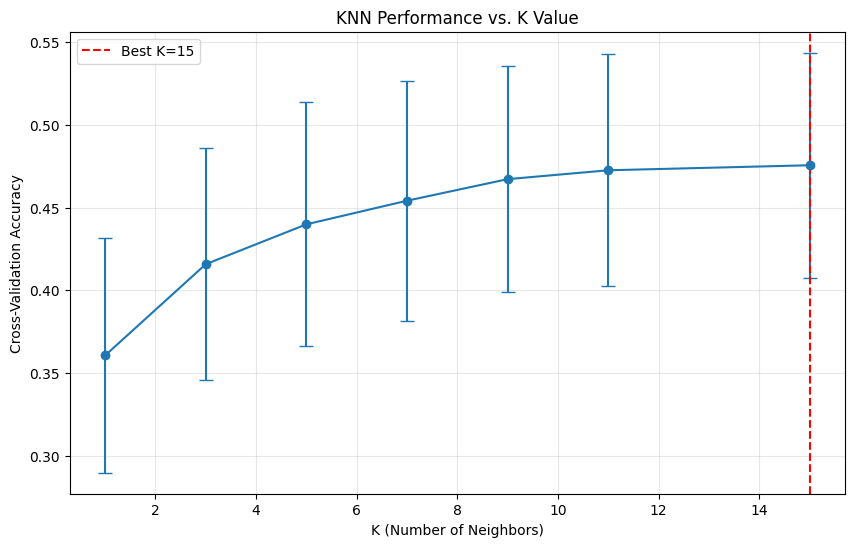

In [18]:
# Visualize K selection
import matplotlib.pyplot as plt

k_values_plot = [r[0] for r in results]
scores_plot = [r[1] for r in results]
stds_plot = [r[2] for r in results]

plt.figure(figsize=(10, 6))
plt.errorbar(k_values_plot, scores_plot, yerr=stds_plot, marker='o', capsize=5)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN Performance vs. K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Save Final Model

In [19]:
# Retrain with best K if different from original
if best_k != router.cfg['hparam']['n_neighbors']:
    print(f"Retraining with optimal K={best_k}...")
    
    # Create new KNN model with best K
    from sklearn.neighbors import KNeighborsClassifier
    from llmrouter.utils import save_model
    
    best_knn = KNeighborsClassifier(
        n_neighbors=best_k,
        weights='uniform',
        algorithm='auto',
        n_jobs=-1
    )
    
    # Train with best K
    best_knn.fit(X, y)
    
    # Save optimal model
    optimal_model_path = trainer.save_model_path.replace('.pkl', '_optimal.pkl')
    save_model(best_knn, optimal_model_path)
    print(f"Optimal model saved to: {optimal_model_path}")
else:
    print(f"Original K={best_k} is already optimal!")

Retraining with optimal K=15...
Successfully saved pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter_optimal.pkl
Optimal model saved to: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter_optimal.pkl


## Summary

In this notebook, we:

1. **Loaded Configuration**: Set up KNNRouter with YAML configuration
2. **Explored Data**: Analyzed training data distribution
3. **Trained Model**: Used KNNRouterTrainer to fit the KNN classifier
4. **Verified Model**: Loaded and tested the saved model
5. **Tuned Hyperparameters**: Found optimal K value using cross-validation

**Next Steps**:
- Use the next part of notebook to perform inference with the trained model
- Experiment with different distance metrics (cosine, euclidean)
- Try weighted voting with `weights='distance'`

# KNNRouter - Inference

This part of notebook demonstrates how to use a trained **KNNRouter** for inference.

## Overview

We will cover:
1. Loading a trained KNNRouter model
2. Single query routing
3. Batch query routing
4. Full inference with API calls
5. Performance evaluation

## 1. Environment Setup

In [34]:
# Import required modules
from llmrouter.models.knnrouter import KNNRouter
from llmrouter.utils import setup_environment, load_model, get_longformer_embedding

setup_environment()
print("Environment setup complete!")

Environment setup complete!


## 2. Configuration

In [23]:
import yaml

# Use inference configuration
# The inference config should have load_model_path set
CONFIG_PATH = "configs/model_config_train/knnrouter.yaml"

# Load configuration
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# Add load_model_path for inference
config['model_path']['load_model_path'] = config['model_path'].get(
    'load_model_path', 
    config['model_path']['save_model_path']
)

print("Configuration loaded!")
print(f"Model path: {config['model_path']['load_model_path']}")

Configuration loaded!
Model path: saved_models/knnrouter/knnrouter.pkl


In [24]:
# Create inference config file
INFERENCE_CONFIG_PATH = "configs/model_config_test/knnrouter_inference.yaml"

os.makedirs(os.path.dirname(INFERENCE_CONFIG_PATH), exist_ok=True)

inference_config = config.copy()
inference_config['model_path']['load_model_path'] = 'saved_models/knnrouter/knnrouter.pkl'

with open(INFERENCE_CONFIG_PATH, 'w') as f:
    yaml.dump(inference_config, f)

print(f"Inference config saved to: {INFERENCE_CONFIG_PATH}")

Inference config saved to: configs/model_config_test/knnrouter_inference.yaml


## 3. Load Trained Router

In [25]:
# Initialize router for inference
router = KNNRouter(yaml_path=INFERENCE_CONFIG_PATH)

print("Router loaded successfully!")
print(f"Number of LLM candidates: {len(router.llm_data)}")
print(f"LLM candidates: {list(router.llm_data.keys())}")

✅ MetaRouter initialized successfully (YAML + data loaded).
Router loaded successfully!
Number of LLM candidates: 14
LLM candidates: ['qwen2.5-7b-instruct', 'codegemma-7b', 'gemma-2-9b-it', 'llama-3.1-8b-instruct', 'llama3-chatqa-1.5-8b', 'mistral-7b-instruct-v0.3', 'llama-3.3-nemotron-super-49b-v1', 'llama-3.1-nemotron-51b-instruct', 'llama3-chatqa-1.5-70b', 'llama3-70b-instruct', 'mixtral-8x7b-instruct-v0.1', 'mixtral-8x22b-instruct-v0.1', 'palmyra-creative-122b', 'mistral-nemo-12b-instruct']


In [32]:
from pathlib import Path
PROJECT_ROOT = Path(os.getcwd()).parent.parent
project_root = os.getcwd()
# Load trained model
model_path = os.path.join(PROJECT_ROOT, config['model_path']['load_model_path'])


if os.path.exists(model_path):
    knn_model = load_model(model_path)
    print(f"Loaded model from: {model_path}")
    print(f"Model classes: {knn_model.classes_}")
else:
    model_path_alt = os.path.join(
        project_root,
        "llmrouter",
        config['model_path']['load_model_path']
        )
    if os.path.exists(model_path_alt):
        knn_model = load_model(model_path_alt)
        print(f"Loaded model from: {model_path_alt}")
        print(f"Model classes: {knn_model.classes_}")
    else:
        print(f"Model not found at: {model_path}")
        print("Please run the training notebook first!")

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Loaded model from: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Model classes: ['codegemma-7b' 'gemma-2-9b-it' 'llama-3.1-8b-instruct'
 'llama-3.1-nemotron-51b-instruct' 'llama-3.3-nemotron-super-49b-v1'
 'llama3-chatqa-1.5-70b' 'llama3-chatqa-1.5-8b' 'mistral-7b-instruct-v0.3'
 'qwen2.5-7b-instruct']


## 4. Single Query Routing

In [27]:
# Example queries for different task types
EXAMPLE_QUERIES = [
    {
        "query": "What is the capital of France?",
        "task_type": "world_knowledge"
    },
    {
        "query": "Solve the equation: 2x + 5 = 15",
        "task_type": "math"
    },
    {
        "query": "Write a Python function to check if a number is prime.",
        "task_type": "code"
    },
    {
        "query": "If all roses are flowers and some flowers fade quickly, can we conclude that some roses fade quickly?",
        "task_type": "reasoning"
    },
    {
        "query": "Explain the theory of relativity in simple terms.",
        "task_type": "explanation"
    }
]

print(f"Prepared {len(EXAMPLE_QUERIES)} example queries")

Prepared 5 example queries


In [28]:
# Route a single query
def route_single_query(query_dict):
    """Route a single query and return the result."""
    result = router.route_single(query_dict)
    return result

# Test with first example
query = EXAMPLE_QUERIES[0]
result = route_single_query(query)

print(f"Query: {query['query']}")
print(f"Task Type: {query['task_type']}")
print(f"Routed to: {result['model_name']}")

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl


Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Query: What is the capital of France?
Task Type: world_knowledge
Routed to: gemma-2-9b-it


In [29]:
# Route all example queries
print("Routing Results:")
print("=" * 80)

for i, query in enumerate(EXAMPLE_QUERIES, 1):
    result = route_single_query(query)
    print(f"\n{i}. Query: {query['query'][:60]}...")
    print(f"   Task: {query['task_type']}")
    print(f"   Routed to: {result['model_name']}")

Routing Results:
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl

1. Query: What is the capital of France?...
   Task: world_knowledge
   Routed to: gemma-2-9b-it
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl

2. Query: Solve the equation: 2x + 5 = 15...
   Task: math
   Routed to: qwen2.5-7b-instruct
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl

3. Query: Write a Python function to check if a number is prime....
   Task: code
   Routed to: llama-3.1-8b-instruct
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl

4. Query: If all roses are flowers and some flowers fade quickly, can ...
   Task: reasoning
   Routed to: qwen2.5-7b-instruct
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl

5. Query: Exp

## 5. Get Routing Probabilities

In [35]:
import numpy as np

def get_routing_probabilities(query_text):
    """Get routing probabilities for all LLM candidates."""
    # Generate embedding
    embedding = get_longformer_embedding(query_text).numpy().reshape(1, -1)
    
    # Get probabilities
    proba = knn_model.predict_proba(embedding)[0]
    
    # Create results dictionary
    results = dict(zip(knn_model.classes_, proba))
    
    # Sort by probability
    results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
    
    return results

# Test with first query
query_text = EXAMPLE_QUERIES[0]['query']
probabilities = get_routing_probabilities(query_text)

print(f"Query: {query_text}")
print("\nRouting Probabilities:")
for model, prob in probabilities.items():
    bar = "#" * int(prob * 50)
    print(f"  {model:30} {prob:.4f} {bar}")

Query: What is the capital of France?

Routing Probabilities:
  gemma-2-9b-it                  0.4000 ####################
  qwen2.5-7b-instruct            0.4000 ####################
  codegemma-7b                   0.2000 ##########
  llama-3.1-8b-instruct          0.0000 
  llama-3.1-nemotron-51b-instruct 0.0000 
  llama-3.3-nemotron-super-49b-v1 0.0000 
  llama3-chatqa-1.5-70b          0.0000 
  llama3-chatqa-1.5-8b           0.0000 
  mistral-7b-instruct-v0.3       0.0000 


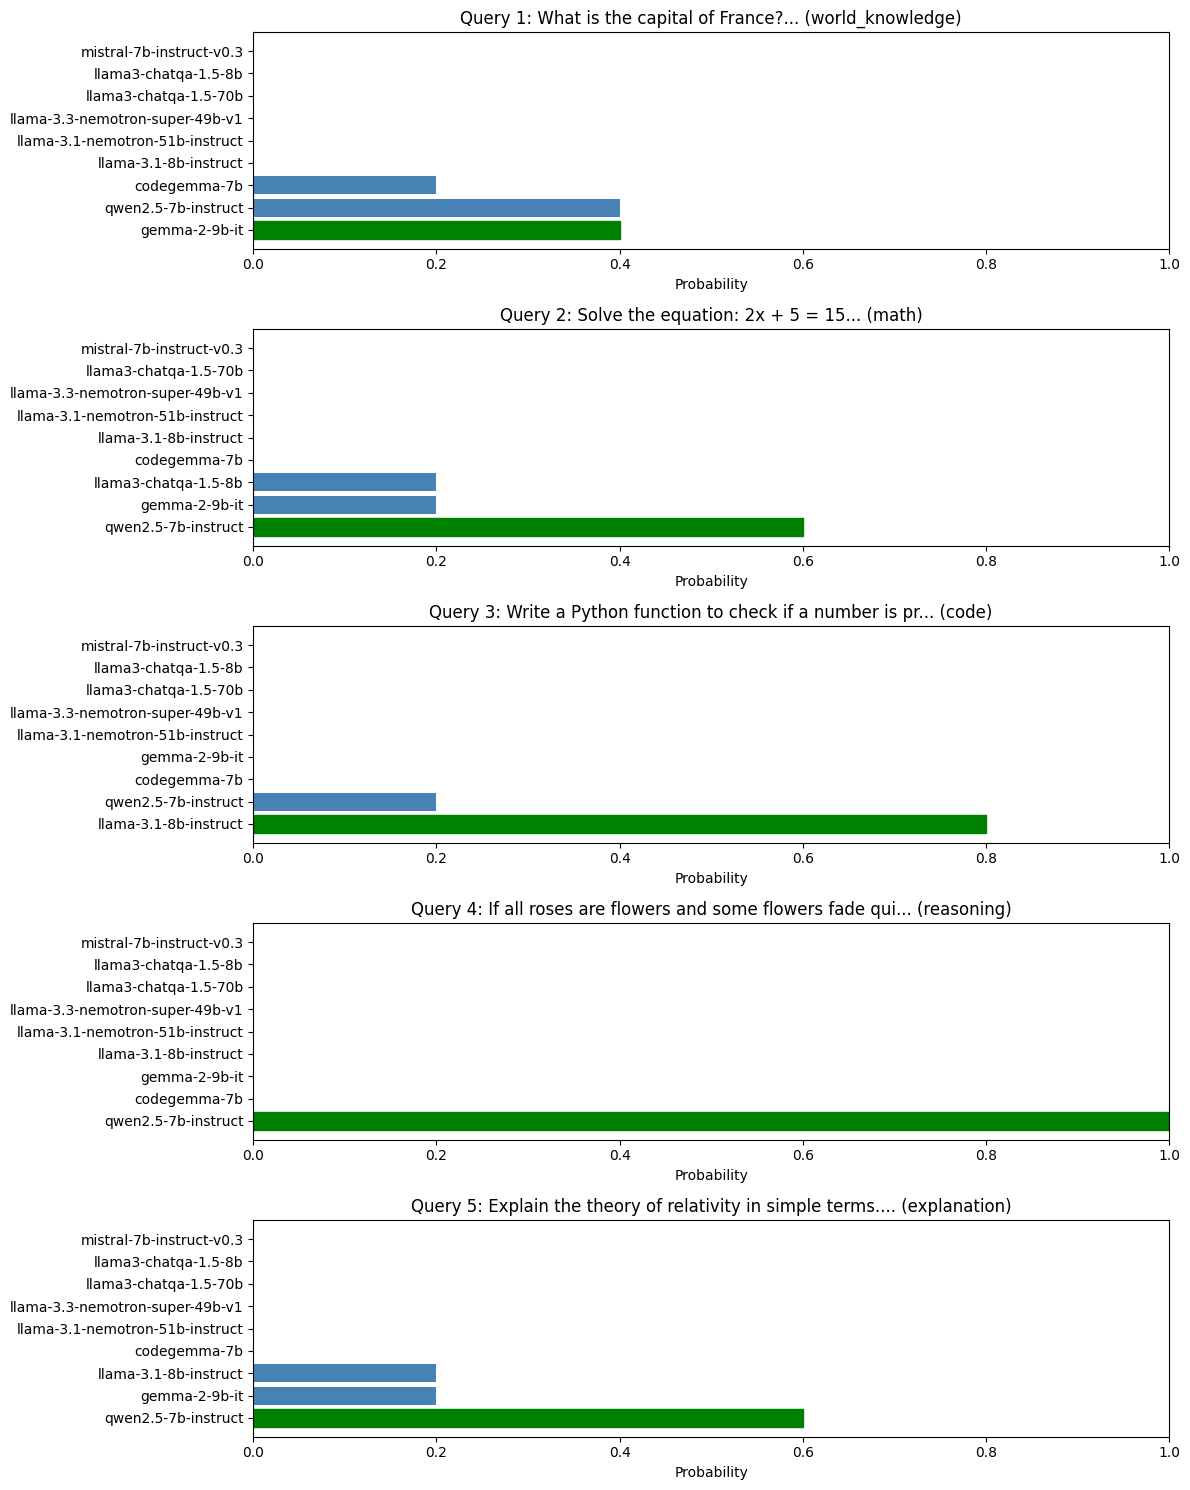

In [36]:
# Visualize routing probabilities for all queries
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(EXAMPLE_QUERIES), 1, figsize=(12, 3*len(EXAMPLE_QUERIES)))

for idx, query in enumerate(EXAMPLE_QUERIES):
    probs = get_routing_probabilities(query['query'])
    
    ax = axes[idx] if len(EXAMPLE_QUERIES) > 1 else axes
    models = list(probs.keys())
    values = list(probs.values())
    
    bars = ax.barh(models, values, color='steelblue')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability')
    ax.set_title(f"Query {idx+1}: {query['query'][:50]}... ({query['task_type']})")
    
    # Highlight the chosen model
    max_idx = values.index(max(values))
    bars[max_idx].set_color('green')

plt.tight_layout()
plt.show()

## 6. Batch Query Routing

### Option 1: Route queries from configuration file

The router automatically loads test data from the path specified in `query_data_test` in the YAML config.

In [37]:
# Load test data for batch routing
if router.query_data_test is not None:
    test_data = router.query_data_test[:20]  # Use first 20 samples
    print(f"Loaded {len(test_data)} test samples")
else:
    print("No test data available. Using example queries.")
    test_data = EXAMPLE_QUERIES

Loaded 20 test samples


In [38]:
# Batch routing (route-only, no API calls)
def batch_route_only(queries):
    """Route multiple queries without calling APIs."""
    results = []
    for query in queries:
        result = router.route_single(query)
        results.append(result)
    return results

# Route batch
batch_results = batch_route_only(test_data)

print(f"Routed {len(batch_results)} queries")

# Show routing distribution
from collections import Counter
model_counts = Counter(r['model_name'] for r in batch_results)

print("\nRouting Distribution:")
for model, count in model_counts.most_common():
    percentage = count / len(batch_results) * 100
    print(f"  {model}: {count} ({percentage:.1f}%)")

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongj

### Option 2: Load queries from your own file

You can also load queries from a custom JSONL file and pass them to the router.

In [ ]:
import json

# Method 1: Load from custom JSONL file
def load_queries_from_file(file_path):
    """Load queries from a JSONL file."""
    queries = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                queries.append(json.loads(line))
    return queries

# Example: Load from the default query test file
QUERY_FILE = "data/example_data/query_data/default_query_test.jsonl"

if os.path.exists(QUERY_FILE):
    file_queries = load_queries_from_file(QUERY_FILE)
    print(f"Loaded {len(file_queries)} queries from file")
    print(f"\nSample query: {file_queries[0]}")
    
    # Route queries from file
    file_results = router.route_batch(batch=file_queries[:10])
    
    print(f"\nRouted {len(file_results)} queries from file:")
    for i, result in enumerate(file_results[:3], 1):
        print(f"  {i}. Query: {result.get('query', '')[:50]}...")
        print(f"     Routed to: {result['model_name']}")
else:
    print(f"File not found: {QUERY_FILE}")
    print("You can create your own JSONL file with format:")
    print('  {"query": "Your question here"}')

In [ ]:
# Method 2: Save routing results to file
def save_results_to_file(results, output_path):
    """Save routing results to a JSONL file."""
    with open(output_path, 'w', encoding='utf-8') as f:
        for result in results:
            f.write(json.dumps(result, ensure_ascii=False) + '\n')
    print(f"Results saved to: {output_path}")

# Example: Save results
OUTPUT_FILE = "outputs/knnrouter_results.jsonl"
os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)

if 'file_results' in dir() and file_results:
    save_results_to_file(file_results, OUTPUT_FILE)
    
    # Verify saved file
    print(f"\nVerifying saved file:")
    with open(OUTPUT_FILE, 'r') as f:
        first_line = json.loads(f.readline())
        print(f"First result: {first_line}")

In [ ]:
# Visualize routing distribution
import matplotlib.pyplot as plt

models = list(model_counts.keys())
counts = list(model_counts.values())

plt.figure(figsize=(10, 6))
plt.pie(counts, labels=models, autopct='%1.1f%%', startangle=90)
plt.title('Query Routing Distribution')
plt.axis('equal')
plt.show()

## 7. Full Inference with API Calls (Optional)

In [40]:
# Check if API keys are available
api_available = bool(
    os.environ.get('OPENAI_API_KEY') or 
    os.environ.get('ANTHROPIC_API_KEY') or
    os.environ.get('API_KEYS')
)

print(f"API keys available: {api_available}")

if not api_available:
    print("\nTo enable full inference with API calls, set one of:")
    print("  - OPENAI_API_KEY")
    print("  - ANTHROPIC_API_KEY")
    print("  - API_KEYS (JSON array of keys)")

API keys available: True


In [ ]:
# Full inference (with API calls) - only if API keys are available
if api_available:
    # Use route_batch which includes API calls
    full_results = router.route_batch(batch=test_data[:5])  # Limit to 5 for demo
    
    print("Full Inference Results:")
    print("=" * 80)
    
    for result in full_results:
        print(f"\nQuery: {result['query'][:60]}...")
        print(f"Routed to: {result['model_name']}")
        print(f"Response: {result.get('response', 'N/A')[:100]}...")
        print(f"Success: {result.get('success', 'N/A')}")
else:
    print("Skipping full inference - no API keys configured")

## 8. Performance Evaluation

In [42]:
# Evaluate routing accuracy on test data
# This compares the router's choice with the oracle (best performing model)

if router.routing_data_test is not None:
    test_df = router.routing_data_test
    
    # Find best model for each query (oracle)
    oracle_best = test_df.loc[
        test_df.groupby('query')['performance'].idxmax()
    ][['query', 'model_name', 'performance']]
    oracle_best.columns = ['query', 'oracle_model', 'oracle_performance']
    
    print(f"Test set: {len(oracle_best)} unique queries")
    print(f"\nOracle model distribution:")
    print(oracle_best['oracle_model'].value_counts())
else:
    print("No test routing data available for evaluation")

Test set: 706 unique queries

Oracle model distribution:
oracle_model
qwen2.5-7b-instruct                278
gemma-2-9b-it                      153
llama-3.1-8b-instruct              104
llama-3.1-nemotron-51b-instruct     51
codegemma-7b                        32
llama3-chatqa-1.5-8b                30
llama-3.3-nemotron-super-49b-v1     25
mistral-7b-instruct-v0.3            24
llama3-chatqa-1.5-70b                9
Name: count, dtype: int64


In [43]:
# Compare router predictions with oracle
if router.routing_data_test is not None:
    from tqdm import tqdm
    
    correct = 0
    total = 0
    results_comparison = []
    
    for _, row in tqdm(oracle_best.iterrows(), total=len(oracle_best), desc="Evaluating"):
        query = row['query']
        oracle_model = row['oracle_model']
        
        # Get router prediction
        result = router.route_single({'query': query})
        predicted_model = result['model_name']
        
        is_correct = predicted_model == oracle_model
        correct += int(is_correct)
        total += 1
        
        results_comparison.append({
            'query': query[:50],
            'oracle': oracle_model,
            'predicted': predicted_model,
            'correct': is_correct
        })
    
    accuracy = correct / total if total > 0 else 0
    print(f"\nRouting Accuracy: {accuracy:.4f} ({correct}/{total})")

Evaluating:   0%|          | 3/706 [00:00<00:26, 26.62it/s]

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl


Evaluating:   1%|▏         | 9/706 [00:00<00:25, 26.86it/s]

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl


Evaluating:   2%|▏         | 15/706 [00:00<00:24, 27.72it/s]

...

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl


Evaluating:  99%|█████████▉| 700/706 [00:24<00:00, 31.93it/s]

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl


Evaluating: 100%|██████████| 706/706 [00:24<00:00, 28.87it/s]

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/knnrouter/knnrouter.pkl

Routing Accuracy: 0.4674 (330/706)


Classification Report:
                                 precision    recall  f1-score   support

                   codegemma-7b       0.16      0.28      0.20        32
                  gemma-2-9b-it       0.44      0.56      0.49       153
          llama-3.1-8b-instruct       0.27      0.22      0.24       104
llama-3.1-nemotron-51b-instruct       0.09      0.02      0.03        51
llama-3.3-nemotron-super-49b-v1       0.33      0.04      0.07        25
          llama3-chatqa-1.5-70b       0.00      0.00      0.00         9
           llama3-chatqa-1.5-8b       0.43      0.10      0.16        30
       mistral-7b-instruct-v0.3       0.20      0.04      0.07        24
            qwen2.5-7b-instruct       0.60      0.74      0.66       278

                       accuracy                           0.47       706
                      macro avg       0.28      0.22      0.22       706
                   weighted avg       0.42      0.47      0.43       706



/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


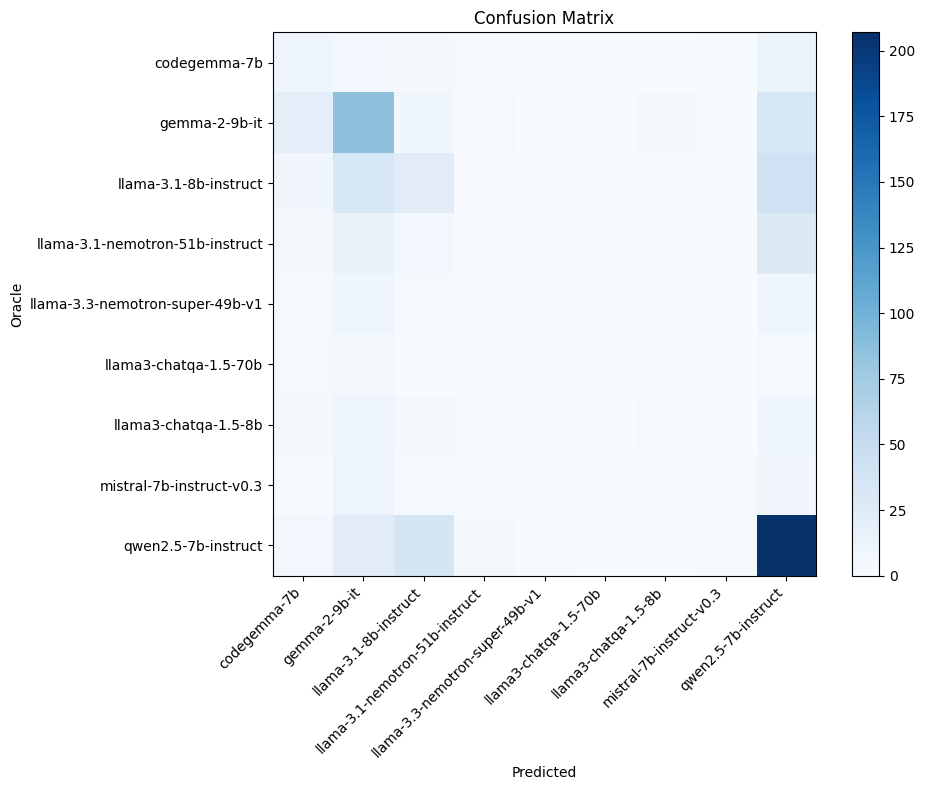

In [44]:
# Show confusion matrix
if router.routing_data_test is not None:
    import pandas as pd
    from sklearn.metrics import confusion_matrix, classification_report
    
    comparison_df = pd.DataFrame(results_comparison)
    
    # Classification report
    print("Classification Report:")
    print(classification_report(comparison_df['oracle'], comparison_df['predicted']))
    
    # Confusion matrix
    labels = sorted(set(comparison_df['oracle']) | set(comparison_df['predicted']))
    cm = confusion_matrix(comparison_df['oracle'], comparison_df['predicted'], labels=labels)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Predicted')
    plt.ylabel('Oracle')
    plt.tight_layout()
    plt.show()

## 9. Using CLI for Inference

In [ ]:
# You can also use the CLI for inference
print("CLI Commands for Inference:")
print("="*60)
print()
print("# Route a single query (route-only, no API call):")
print('llmrouter infer --router knnrouter --config configs/model_config_test/knnrouter_inference.yaml --query "What is AI?" --route-only')
print()
print("# Route with full inference (API call):")
print('llmrouter infer --router knnrouter --config configs/model_config_test/knnrouter_inference.yaml --query "What is AI?"')
print()
print("# Batch inference from file:")
print('llmrouter infer --router knnrouter --config configs/model_config_test/knnrouter_inference.yaml --input queries.txt --output results.json')

## Summary

In this notebook, we:

1. **Loaded Trained Model**: Set up KNNRouter with trained model
2. **Single Query Routing**: Routed individual queries to LLMs
3. **Routing Probabilities**: Analyzed routing confidence
4. **Batch Routing**: Processed multiple queries efficiently
5. **Full Inference**: Called LLM APIs (when available)
6. **Performance Evaluation**: Compared with oracle performance

**Key Findings**:
- KNNRouter provides interpretable routing decisions
- Routing probabilities show model confidence
- Performance can be tuned via K and distance metric

**Next Steps**:
- Try different routers (SVMRouter, MLPRouter, etc.)
- Experiment with ensemble routing
- Deploy as API service